<a href="https://colab.research.google.com/github/SLCFLAB/Fintech2026-2/blob/main/DL08_CNN/CNN_2_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN 2. Fashion-MNIST로 CNN 학습 및 모델 내부 관찰

| 순서 | 내용 |
|---|---|
| 1 | 데이터 준비 |
| 2 | CNN vs MLP 학습 및 비교 |
| 3 | 평가: accuracy 너머 보기 (confusion matrix, 틀린 샘플, confidence) |
| 4 | 모델 내부: 학습된 filter와 feature map |
| 5 | 약점 찾기: 이미지 shift 실험 → data augmentation |

- Colab: `런타임 → 런타임 유형 변경 → T4 GPU` 선택 권장 (CPU로도 돌아가지만 느림)
- 전체 실행 시간: T4 GPU 기준 약 3~4분

출처: https://github.com/Harry24k/Pytorch-Basic

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"   # GPU 있으면 GPU 사용
torch.manual_seed(0)
print("device:", DEVICE)

device: cuda


## 1. 데이터 준비

- **Fashion-MNIST**: 옷·신발·가방 흑백 이미지 10종 (28×28, 학습 60,000장).
  - MNIST와 형식은 같지만 더 어려움 (Shirt / T-shirt / Coat / Pullover 처럼 헷갈리는 class가 있음)
- `transforms.ToTensor()`: PIL 이미지(0\~255) → Tensor(0\~1), shape `[C, H, W]`

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.2MB/s]


train: 60000 | test: 10000 | 1 epoch = 600 steps


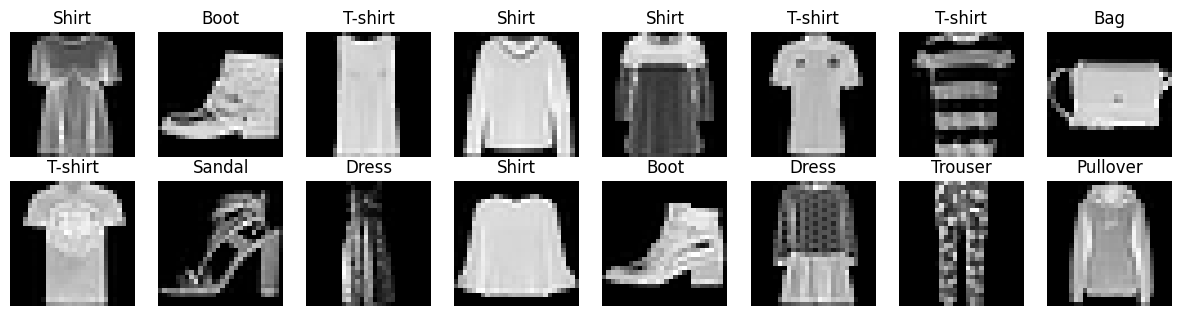

In [2]:
DATASET = "FashionMNIST"   # "FashionMNIST" or "MNIST"

DS = getattr(dsets, DATASET)
CLASSES = ([str(i) for i in range(10)] if DATASET == "MNIST" else
           ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Boot"])

train_data = DS(root="./data", train=True,  download=True, transform=transforms.ToTensor())
test_data  = DS(root="./data", train=False, download=True, transform=transforms.ToTensor())

BATCH_SIZE = 100
# shuffle=True: 매 epoch마다 순서 섞음 → 같은 순서 반복 학습으로 인한 편향 방지 (test는 섞을 필요 없음)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=1000,       shuffle=False, num_workers=2)

print("train:", len(train_data), "| test:", len(test_data), "| 1 epoch =", len(train_loader), "steps")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, idx in zip(axes.flat, torch.randint(len(train_data), (16,))):
    x, y = train_data[idx]
    ax.imshow(x[0], cmap="gray"); ax.set_title(CLASSES[y]); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. 모델 정의: CNN vs MLP

In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layer = nn.Sequential(        # 입력: [B, 1, 28, 28]
            nn.Conv2d(1, 16, 5),                # [B, 16, 24, 24]  edge 같은 단순 패턴
            nn.ReLU(),
            nn.Conv2d(16, 32, 5),               # [B, 32, 20, 20]
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                 # [B, 32, 10, 10]  크기 절반
            nn.Conv2d(32, 64, 5),               # [B, 64, 6, 6]    더 복잡한 패턴 조합
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                 # [B, 64, 3, 3]
        )
        self.fc_layer = nn.Sequential(          # 추출한 feature로 분류
            nn.Flatten(),                       # [B, 64*3*3=576]
            nn.Linear(64 * 3 * 3, 100),
            nn.ReLU(),
            nn.Linear(100, 10),                 # class 10개의 점수(logit). softmax는 loss 안에서 처리됨
        )

    def forward(self, x):
        return self.fc_layer(self.conv_layer(x))


class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                       # [B, 784] ← 픽셀 위치 정보(2D 구조) 사라짐
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)


count_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"CNN parameters: {count_params(CNN()):,}")
print(f"MLP parameters: {count_params(MLP()):,}")

CNN parameters: 123,222
MLP parameters: 235,146


### 학습 / 평가 함수

학습 루프 5단계는 모든 PyTorch 모델에서 동일함 → **이 5줄의 의미는 꼭 이해하고 넘어가기**.

1. `pred = model(x)` : forward
2. `loss = criterion(pred, y)` : 정답과 비교
3. `optimizer.zero_grad()` : 이전 step gradient 초기화 (안 하면 누적됨)
4. `loss.backward()` : backprop으로 gradient 계산
5. `optimizer.step()` : weight 갱신

In [4]:
def train(model, loader, epochs=3, lr=1e-3):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()            # 분류 문제 표준 loss (내부에서 softmax 포함)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(epochs):
        model.train()                            # 학습 모드 (Dropout/BatchNorm 있을 때 중요)
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            loss = criterion(model(x), y)        # 1) forward  2) loss
            optimizer.zero_grad()                # 3) gradient 초기화
            loss.backward()                      # 4) backprop
            optimizer.step()                     # 5) weight 갱신
            history.append(loss.item())
        print(f"  epoch {epoch+1}/{epochs}  loss {np.mean(history[-len(loader):]):.4f}  test acc {evaluate(model, test_loader):.2f}%")
    return history


@torch.no_grad()                                 # 평가 때는 gradient 계산 불필요 → 메모리/속도 이득
def predict(model, loader, transform=None):
    # 전체 데이터에 대한 softmax 확률과 정답 반환
    model.eval()                                 # 평가 모드
    probs, labels = [], []
    for x, y in loader:
        if transform is not None:
            x = transform(x)
        probs.append(F.softmax(model(x.to(DEVICE)), dim=1).cpu())
        labels.append(y)
    return torch.cat(probs), torch.cat(labels)


def evaluate(model, loader, transform=None):
    probs, labels = predict(model, loader, transform)
    return (probs.argmax(1) == labels).float().mean().item() * 100

[CNN]
  epoch 1/3  loss 0.6238  test acc 83.23%
  epoch 2/3  loss 0.3779  test acc 87.04%
  epoch 3/3  loss 0.3141  test acc 88.13%
[MLP]
  epoch 1/3  loss 0.5425  test acc 83.67%
  epoch 2/3  loss 0.3794  test acc 86.10%
  epoch 3/3  loss 0.3380  test acc 86.17%


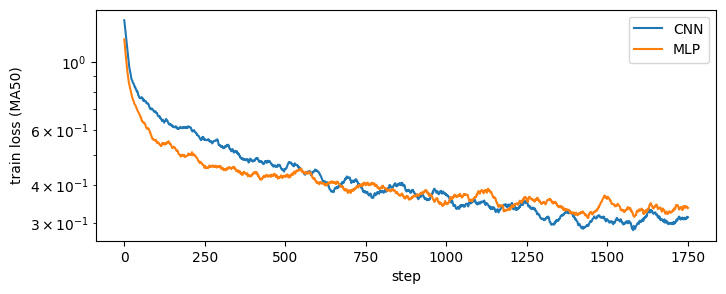

In [5]:
print("[CNN]"); cnn = CNN(); hist_cnn = train(cnn, train_loader)
print("[MLP]"); mlp = MLP(); hist_mlp = train(mlp, train_loader)

smooth = lambda h: np.convolve(h, np.ones(50) / 50, mode="valid")   # 1D conv로 이동평균 (CNN 1 참고)
plt.figure(figsize=(8, 3))
plt.plot(smooth(hist_cnn), label="CNN"); plt.plot(smooth(hist_mlp), label="MLP")
plt.yscale("log"); plt.xlabel("step"); plt.ylabel("train loss (MA50)"); plt.legend(); plt.show()

- CNN이 MLP의 **절반 정도 parameter로 약간 더 높은 정확도** 를 냄. 다만 원래 위치 그대로의 test에선 차이가 1~2%p로 크지 않음
- 참고: 손글씨 MNIST는 더 쉬워서 CNN/MLP 모두 97~99% 나옴

## 3. Evalaution


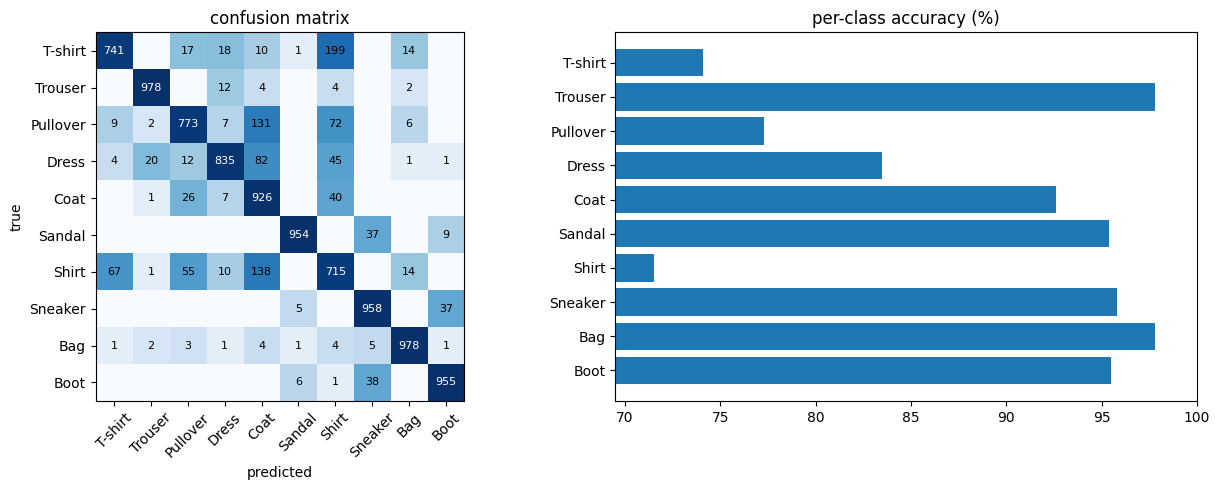

In [6]:
probs, labels = predict(cnn, test_loader)
preds = probs.argmax(1)

# confusion matrix: 행 = 정답, 열 = 예측
cm = torch.bincount(labels * 10 + preds, minlength=100).view(10, 10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(torch.log1p(cm), cmap="Blues")          # log scale: 대각선이 너무 커서 오답이 안 보이는 것 방지
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            axes[0].text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=8,
                         color="white" if i == j else "black")
axes[0].set_xticks(range(10), CLASSES, rotation=45); axes[0].set_yticks(range(10), CLASSES)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true"); axes[0].set_title("confusion matrix")

per_class = cm.diag() / cm.sum(1) * 100
axes[1].barh(CLASSES, per_class); axes[1].set_xlim(per_class.min() - 2, 100)
axes[1].set_title("per-class accuracy (%)"); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

### 틀린 샘플들 (with confidence)

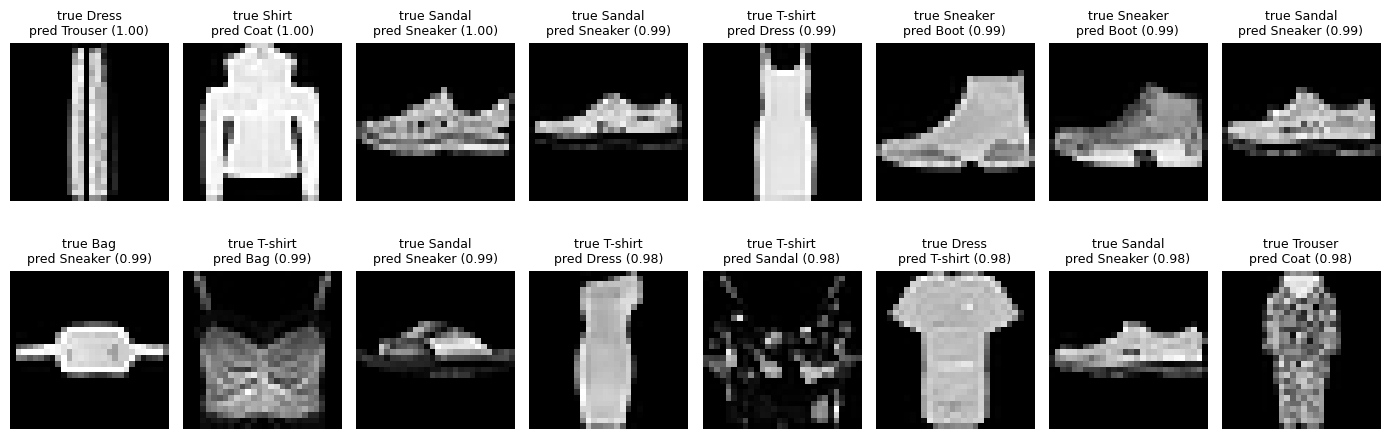

In [7]:
wrong = (preds != labels).nonzero().flatten()
conf = probs.max(1).values
wrong = wrong[conf[wrong].argsort(descending=True)][:16]   # 확신도 높은 오답 순 정렬

fig, axes = plt.subplots(2, 8, figsize=(14, 5))
for ax, i in zip(axes.flat, wrong):
    ax.imshow(test_data[i][0][0], cmap="gray")
    ax.set_title(f"true {CLASSES[labels[i]]}\npred {CLASSES[preds[i]]} ({conf[i]:.2f})", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

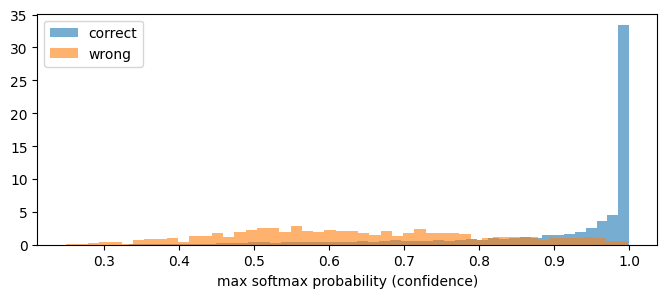

오답 중 confidence > 0.9 비율: 9.0%


In [8]:
correct = preds == labels
plt.figure(figsize=(8, 3))
plt.hist(conf[correct], bins=50, alpha=0.6, label="correct", density=True)
plt.hist(conf[~correct], bins=50, alpha=0.6, label="wrong", density=True)
plt.xlabel("max softmax probability (confidence)"); plt.legend(); plt.show()
print(f"오답 중 confidence > 0.9 비율: {(conf[~correct] > 0.9).float().mean()*100:.1f}%")

- 틀린 샘플 중 일부는 사람이 봐도 애매함 (28×28 흑백으로 Shirt와 T-shirt 구분은 사람에게도 어려움) → **데이터 자체의 한계 / label noise** 일 수도 있음
- 오답인데 confidence가 높은 경우가 있음 → softmax 확률 ≠ 진짜 확률. 금융·의료처럼 틀리면 비싼 분야에선 **calibration** 또는 "확신 낮으면 사람에게 넘기기" 설계 필요

## 4. 모델 내부 들여다보기

CNN 1에서 사람이 만든 edge filter를 봤음. **학습된 첫 layer filter** 는 어떻게 생겼을까?

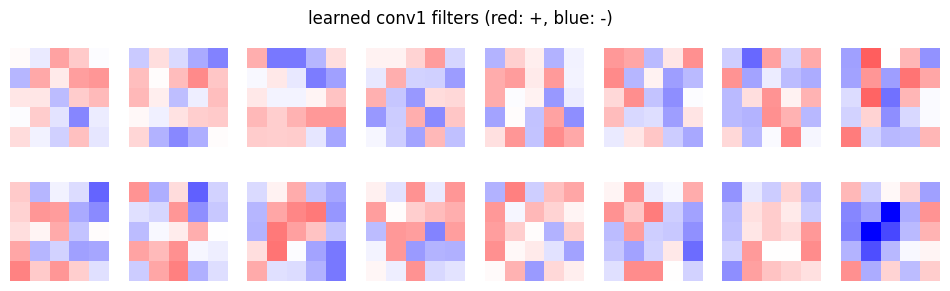

In [9]:
w = cnn.conv_layer[0].weight.detach().cpu()      # [16, 1, 5, 5]: 5x5 filter 16개
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(w[i, 0], cmap="bwr", vmin=-w.abs().max(), vmax=w.abs().max()); ax.axis("off")
plt.suptitle("learned conv1 filters (red: +, blue: -)"); plt.show()

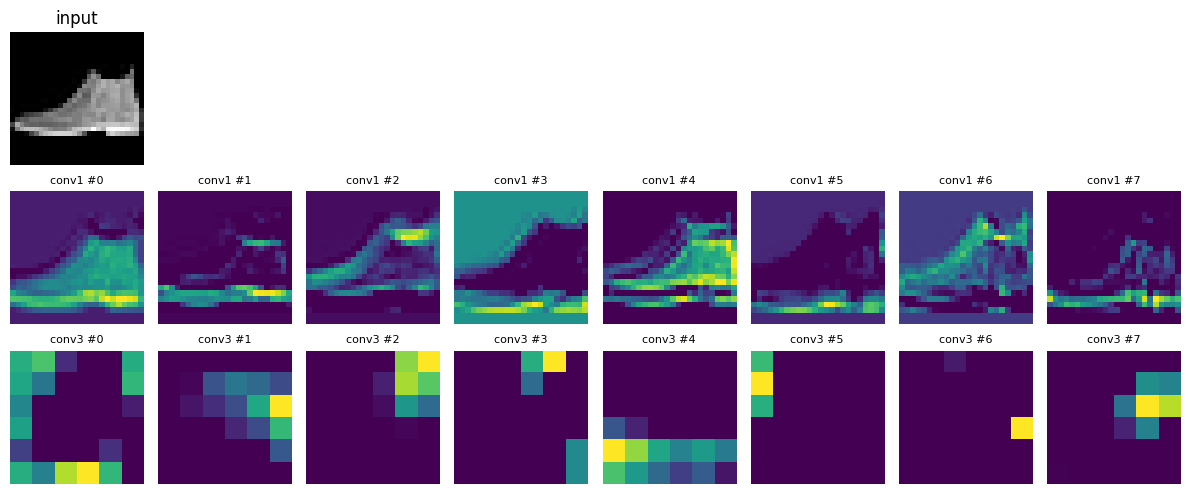

In [10]:
# 이미지 하나가 layer를 지나며 어떻게 바뀌는지 (feature map)
x0 = test_data[0][0].unsqueeze(0).to(DEVICE)
cnn.eval()
with torch.no_grad():
    f1 = cnn.conv_layer[:2](x0)[0].cpu()         # conv1 + ReLU 출력: [16, 24, 24]
    f3 = cnn.conv_layer[:7](x0)[0].cpu()         # conv3 + ReLU 출력: [64, 6, 6]

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
axes[0, 0].imshow(x0[0, 0].cpu(), cmap="gray"); axes[0, 0].set_title("input")
for ax in axes[0, 1:]: ax.remove()
for i in range(8):
    axes[1, i].imshow(f1[i], cmap="viridis"); axes[1, i].set_title(f"conv1 #{i}", fontsize=8)
    axes[2, i].imshow(f3[i], cmap="viridis"); axes[2, i].set_title(f"conv3 #{i}", fontsize=8)
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

- 첫 layer: 방향별 edge/윤곽을 감지하는 filter가 학습됨 (사람이 만든 Sobel filter와 비슷한 모양도 보임)
- 깊은 layer(6×6): 해상도는 낮아지고, 사람이 해석하기 어려운 **추상적 특징** 이 됨

## 5. 이미지를 옆으로 옮기면 (shift)?

Fashion-MNIST는 모든 물체가 **이미지 중앙에 정렬** 되어 있음. 실제 서비스 데이터(사용자가 직접 찍은 상품 사진 등)는 그렇지 않음.
test 이미지를 좌우로 몇 픽셀 옮겨서 정확도가 어떻게 되는지 확인해봄.

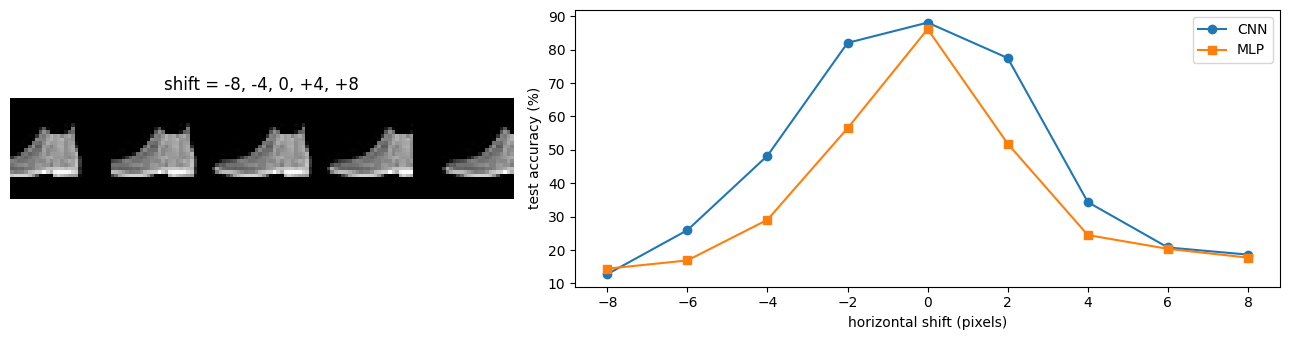

In [11]:
def shift_images(x, dx):
    # 이미지를 가로로 dx 픽셀 이동 (빈 곳은 0으로 채움)
    out = torch.zeros_like(x)
    if dx > 0:   out[..., dx:] = x[..., :-dx]
    elif dx < 0: out[..., :dx] = x[..., -dx:]
    else:        out = x
    return out

SHIFTS = [-8, -6, -4, -2, 0, 2, 4, 6, 8]
def shift_curve(model):
    return [evaluate(model, test_loader, transform=lambda x, d=d: shift_images(x, d)) for d in SHIFTS]

acc_cnn, acc_mlp = shift_curve(cnn), shift_curve(mlp)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), gridspec_kw={"width_ratios": [1, 1.4]})
axes[0].imshow(torch.cat([shift_images(test_data[0][0], d)[0] for d in [-8, -4, 0, 4, 8]], dim=1), cmap="gray")
axes[0].set_title("shift = -8, -4, 0, +4, +8"); axes[0].axis("off")
axes[1].plot(SHIFTS, acc_cnn, "o-", label="CNN"); axes[1].plot(SHIFTS, acc_mlp, "s-", label="MLP")
axes[1].set_xlabel("horizontal shift (pixels)"); axes[1].set_ylabel("test accuracy (%)"); axes[1].legend()
plt.tight_layout(); plt.show()

- CNN이 MLP보다는 낫지만, **몇 픽셀만 옮겨도 정확도가 크게 떨어짐**
- 원인: 학습 데이터에 *옮겨진 이미지* 가 없었음. 모델은 **학습 데이터 분포 안에서만** 잘 동작함 (distribution shift)

### 해결: Data augmentation

학습할 때 이미지를 **무작위로 옮겨서** 넣으면, 모델이 "위치가 달라도 같은 물건"임을 데이터로부터 배움.

[CNN + augmentation]
  epoch 1/3  loss 0.9455  test acc 73.75%
  epoch 2/3  loss 0.6484  test acc 77.39%
  epoch 3/3  loss 0.5733  test acc 78.49%


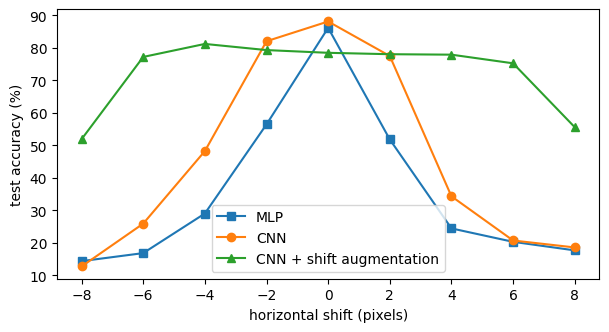

In [12]:
aug_transform = transforms.Compose([
    # 매 step마다 가로/세로 최대 20%(약 6픽셀) 범위에서 랜덤 이동 → 같은 이미지도 매번 다르게 보임
    # (30%로 키우면 옷이 이미지 밖으로 많이 잘려나가서 원래 위치 정확도가 크게 떨어짐)
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
    transforms.ToTensor(),
])
train_aug = DS(root="./data", train=True, download=True, transform=aug_transform)
train_aug_loader = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

print("[CNN + augmentation]")
cnn_aug = CNN()
_ = train(cnn_aug, train_aug_loader, epochs=3)
acc_cnn_aug = shift_curve(cnn_aug)

plt.figure(figsize=(7, 3.5))
plt.plot(SHIFTS, acc_mlp, "s-", label="MLP")
plt.plot(SHIFTS, acc_cnn, "o-", label="CNN")
plt.plot(SHIFTS, acc_cnn_aug, "^-", label="CNN + shift augmentation")
plt.xlabel("horizontal shift (pixels)"); plt.ylabel("test accuracy (%)"); plt.legend(); plt.show()

- 학습 때 본 이동 범위(약 ±6픽셀) 안에서는 정확도가 거의 유지됨. 그 범위를 넘으면(±8) 다시 떨어짐
- 원래 위치(shift 0) 정확도는 약간 낮아짐 → 같은 epoch 동안 더 어려운 문제를 풀었기 때문
  - 그래서 augmentation 범위는 실제 환경에서 예상되는 변형 크기에 맞춰야 함
- 모델 구조를 바꾸는 것보다 데이터를 실제 상황에 맞게 만드는 것이 더 효과적인 경우가 많음.